In [ ]:
!pip install git+https://github.com/MSMRo/signalDraw-isb.git

  Cloning https://github.com/MSMRo/signalDraw-isb.git to /tmp/pip-req-build-1rstfsax
  Running command git clone --filter=blob:none --quiet https://github.com/MSMRo/signalDraw-isb.git /tmp/pip-req-build-1rstfsax
  Resolved https://github.com/MSMRo/signalDraw-isb.git to commit ff5c22c821b47b98f0f8c154c163540086ae2b8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.8 MB/s eta 0:00:00
  Created wheel for signaldraw-isb: filename=signaldraw_isb-0.1.0-py3-none-any.whl size=7729 sha256=3ef41898e99f96dc9c2d220a0bbd670ef7f235f45497347820676ba944915ca1
  Stored in directory: /tmp/pip-ephem-wheel-cache-6imbgobt/wheels/a1/6a/b2/5fbb64642172e5c20aeab3e137b6f969bfed7f9c1dafde72b1
Successfully built signaldraw-isb


In [ ]:
from signaldraw_isb import SignalDraw

ui = SignalDraw()
ui

In [ ]:
# Retorna una lista con todas las señales usadas
# signals[0] es la señal resultante de la suma
# signals[1:] son los senos trabajados
ui.signals



[]

In [ ]:
# fs retorna una lista de todas las frecuencias usadas
# fs[0] es 0 si se usan diferentes fs en cada señal, si no es la misma usada en todas.
# fs[1:] son las frecuencias de muestreo de cada señal senoidal
ui.fs

[]

In [ ]:

# Retorna una lista de numpy arrays de todos los signals individuales
ui.signals_numpy

[]

In [ ]:
# Retorna un numpy array con el result signal
ui.signal_numpy


array([], dtype=float64)

In [ ]:
import numpy as np
from scipy.signal import firwin, lfilter, filtfilt, butter, medfilt, iirnotch, correlate, resample
import matplotlib.pyplot as plt

Ejercicio 1:
Genere tres señales:
- 5 Hz
- 20 Hz
- 80 Hz

Diseñe un filtro pasa banda que permita únicamente:
15 Hz a 30 Hz

Presente: Señal temporal y FFT antes/después

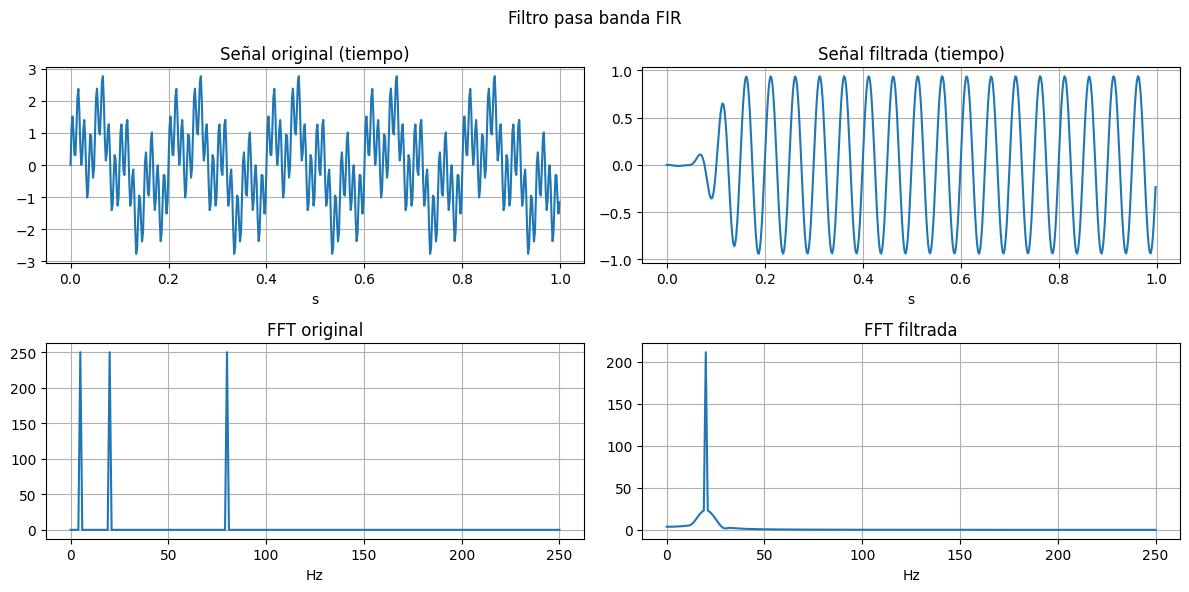

In [ ]:
fs=500
t=np.arange(0, 1, 1/fs)

s1=np.sin(2*np.pi*5*t)   #5 Hz
s2=np.sin(2*np.pi*20*t)   #20 Hz
s3=np.sin(2*np.pi*80*t)   #80 Hz
signal=s1+s2+s3

#Filtro FIR pasa banda 15–30 Hz
N=101  # orden impar, requerido por firwin
fir=firwin(N, [15, 30], pass_zero=False, fs=fs)

#Aplicamos el filtro
filtered=lfilter(fir, 1.0, signal)

#Graficamos la señal
freqs=np.fft.rfftfreq(len(t), 1/fs)

fig, axs=plt.subplots(2, 2, figsize=(12, 6))
axs[0,0].plot(t, signal);
axs[0,0].set_title("Señal original (tiempo)");
axs[0,0].set_xlabel("s")
axs[0,1].plot(t, filtered);
axs[0,1].set_title("Señal filtrada (tiempo)");
axs[0,1].set_xlabel("s")
axs[1,0].plot(freqs, np.abs(np.fft.rfft(signal)));
axs[1,0].set_title("FFT original");
axs[1,0].set_xlabel("Hz")
axs[1,1].plot(freqs, np.abs(np.fft.rfft(filtered)));
axs[1,1].set_title("FFT filtrada");
axs[1,1].set_xlabel("Hz")
for ax in axs.flat:
  ax.grid(True)
plt.suptitle("Filtro pasa banda FIR")
plt.tight_layout()
plt.show()

Ejercicio 2:

Genere

- ECG sintético

- Ruido blanco

- Interferencia de alta frecuencia

Diseñe: Low pass and band pass


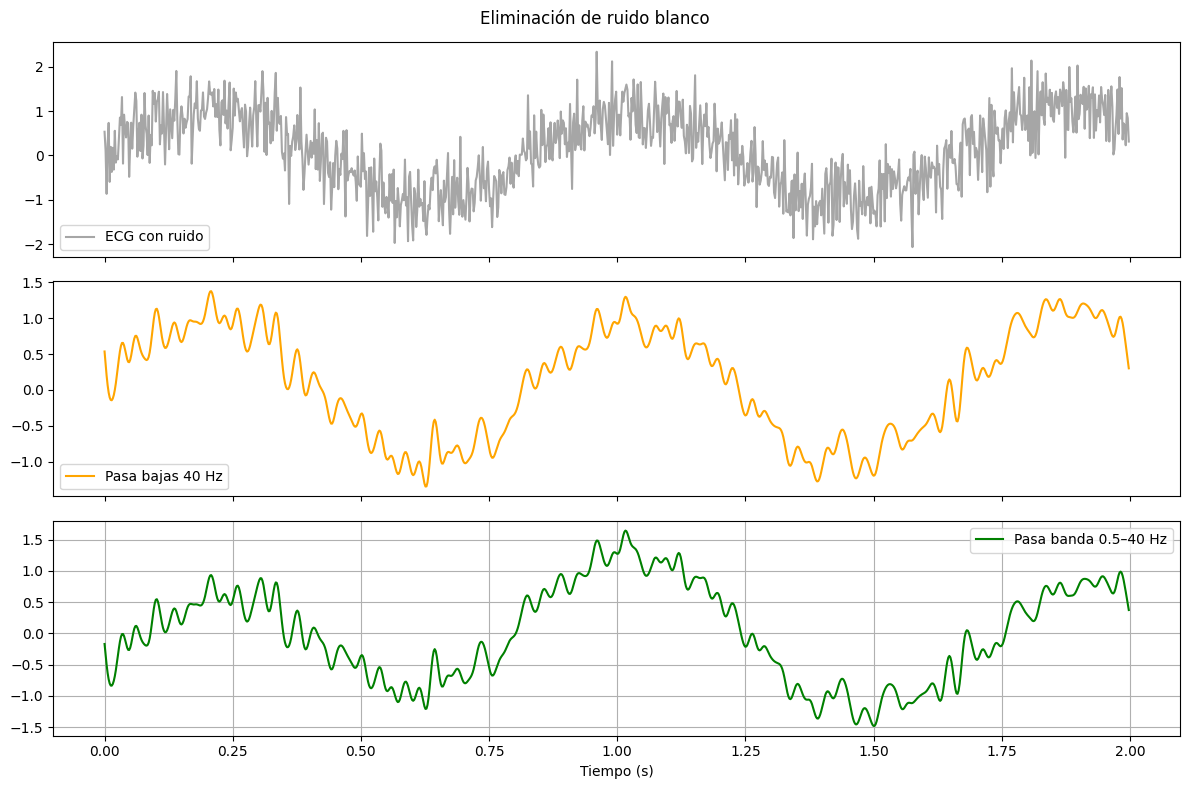

In [ ]:
fs=500
t=np.arange(0, 2, 1/fs)

#ECG sintético + ruido blanco
ecg_limpio=np.sin(2*np.pi*1.2*t)
#Ruido blanco gaussiano
ruido=0.5*np.random.randn(len(t))
ecg_ruidoso=ecg_limpio+ruido

#Filtro pasa bajas Butterworth
#Orden 4, corte 40 Hz
b, a=butter(4, 40, btype='low', fs=fs)
#filtfilt = cero fase, sin retardo
filtrado_lp=filtfilt(b, a, ecg_ruidoso)

#Filtro pasa banda Butterworth
b2, a2=butter(4, [0.5, 40], btype='band', fs=fs)
filtrado_bp=filtfilt(b2, a2, ecg_ruidoso)

#Graficamos
fig, axs=plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axs[0].plot(t, ecg_ruidoso, alpha=0.7, label="ECG con ruido", color='gray')
axs[1].plot(t, filtrado_lp, label="Pasa bajas 40 Hz", color='orange')
axs[2].plot(t, filtrado_bp, label="Pasa banda 0.5–40 Hz", color='green')
for ax in axs:
  ax.legend();
  ax.grid(True);
  ax.set_xlabel("Tiempo (s)")
plt.suptitle("Eliminación de ruido blanco")
plt.tight_layout()
plt.show()

Ejercicio 3:

Genere:

- Señal EEG simulada
- 10 spikes aleatorios

Compare:

- FIR lowpass
- Filtro mediana

Explique cuál funciona mejor.

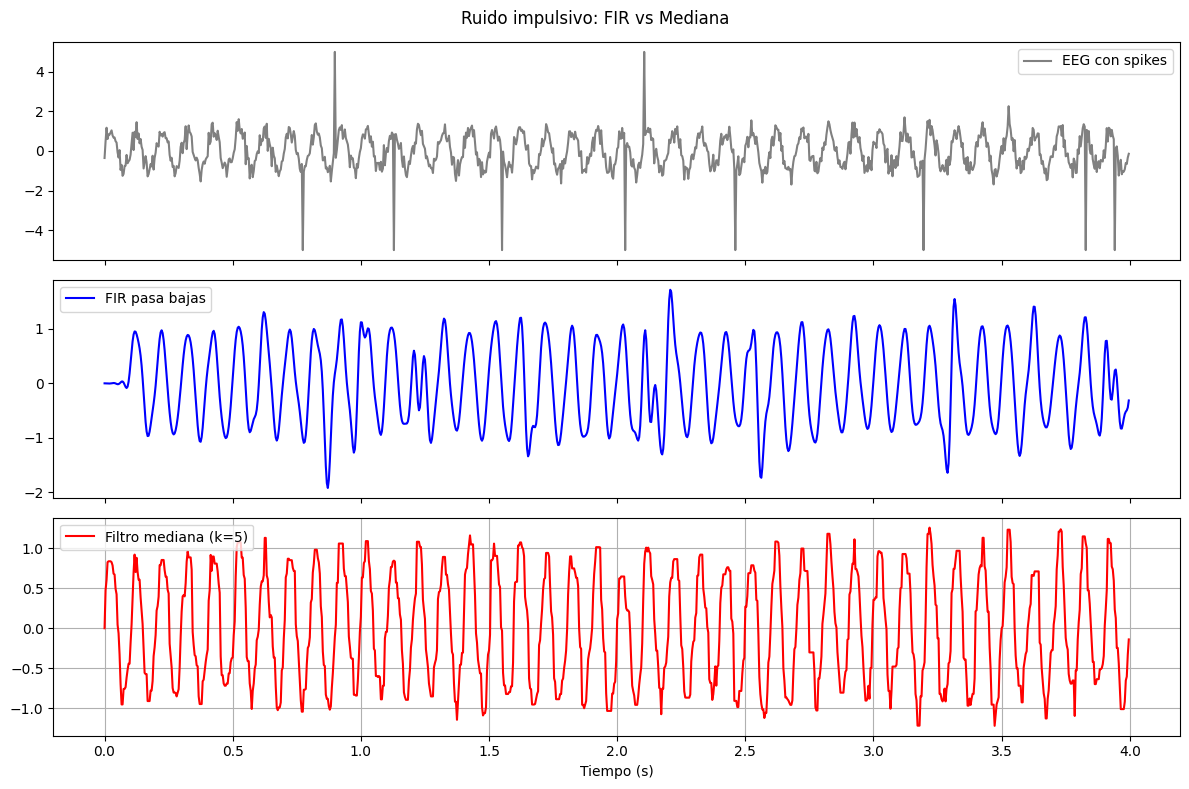

In [ ]:
fs=256
t=np.arange(0, 4, 1/fs)
eeg=np.sin(2*np.pi*10*t) + 0.3*np.random.randn(len(t))

#Agregar 10 spikes aleatorios
eeg_spikes=eeg.copy()
spike_pos=np.random.choice(len(t), 10, replace=False)
eeg_spikes[spike_pos] = np.random.choice([-5, 5], 10)

#Filtro FIR pasa bajas
fir=firwin(51, 30, fs=fs)
filtrado_fir=lfilter(fir, 1.0, eeg_spikes)

#Filtro mediana
filtrado_med=medfilt(eeg_spikes, kernel_size=5)   #Ventana de 5 muestras

#Graficamos
fig, axs=plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axs[0].plot(t, eeg_spikes, label="EEG con spikes", color='gray')
axs[1].plot(t, filtrado_fir, label="FIR pasa bajas", color='blue')
axs[2].plot(t, filtrado_med, label="Filtro mediana (k=5)", color='red')
for ax in axs:
  ax.legend();
  ax.grid(True);
  ax.set_xlabel("Tiempo (s)")
plt.suptitle("Ruido impulsivo: FIR vs Mediana")
plt.tight_layout()
plt.show()

Ejercicio 4:

Simule:
* ECG
* Ruido 60 Hz
* Ruido blanco

Diseñe un pipeline que elimine:
* Interferencia eléctrica
* Ruido de alta frecuencia

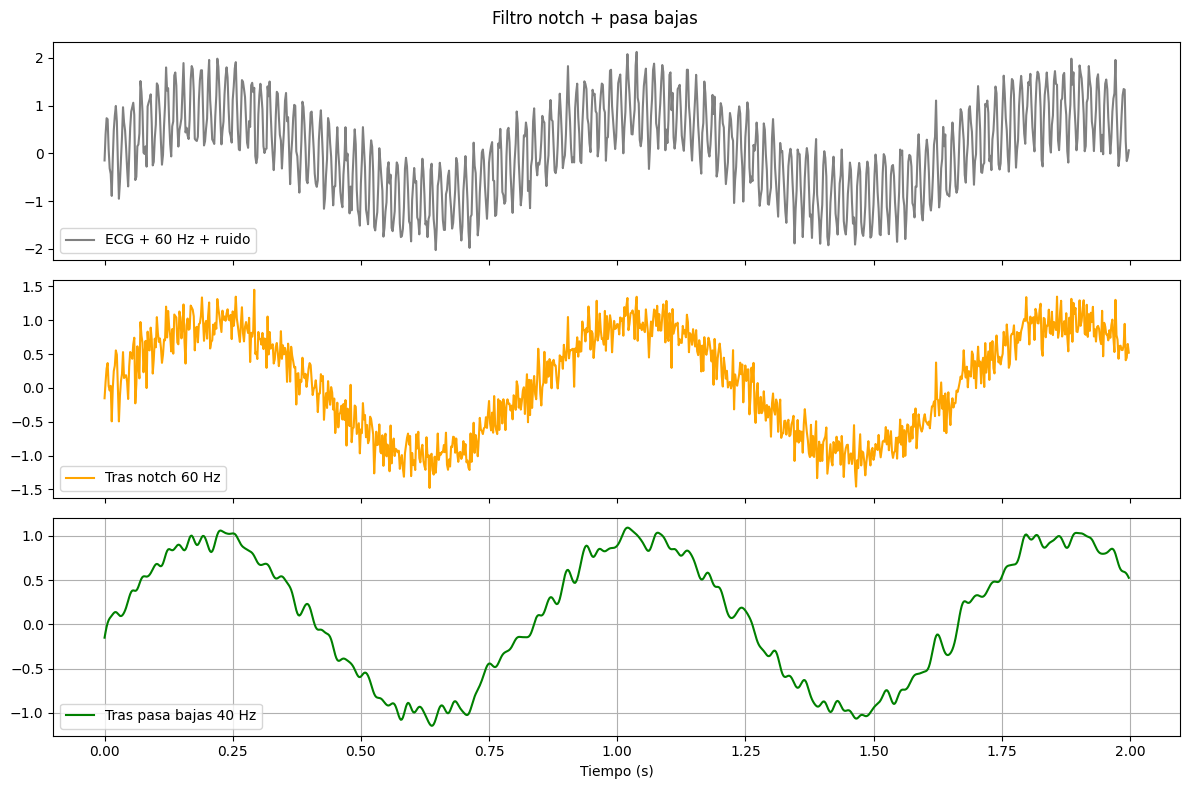

In [ ]:
fs=500
t=np.arange(0, 2, 1/fs)

#Señal contaminada
#ECG
ecg=np.sin(2*np.pi*1.2*t)
#Interferencia red eléctrica
red=0.8*np.sin(2*np.pi*60*t)
#Ruido blanco leve
ruido=0.2*np.random.randn(len(t))
noisy=ecg + red + ruido

#Filtro notch en 60 Hz
#Q=30
b_n, a_n=iirnotch(60, Q=30, fs=fs)
sin_60=filtfilt(b_n, a_n, noisy)

#Filtro pasa bajas para ruido residual
b_lp, a_lp=butter(4, 40, btype='low', fs=fs)
limpio=filtfilt(b_lp, a_lp, sin_60)

#Graficamos
fig, axs=plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axs[0].plot(t, noisy,  label="ECG + 60 Hz + ruido", color='gray')
axs[1].plot(t, sin_60, label="Tras notch 60 Hz", color='orange')
axs[2].plot(t, limpio, label="Tras pasa bajas 40 Hz", color='green')
for ax in axs:
  ax.legend();
  ax.grid(True);
  ax.set_xlabel("Tiempo (s)")
plt.suptitle("Filtro notch + pasa bajas")
plt.tight_layout()
plt.show()

Ejercicio 5:

Genere:
* ECG
* Respiración
* Acelerómetro

Cada señal debe tener:
* Delay distinto 2s y ruido gausiano.
* Sincronice todas usando correlación cruzada.

Delay estimado respiración:  -584 muestras = -1.17 s
Delay estimado acelerómetro: 354 muestras = 0.71 s


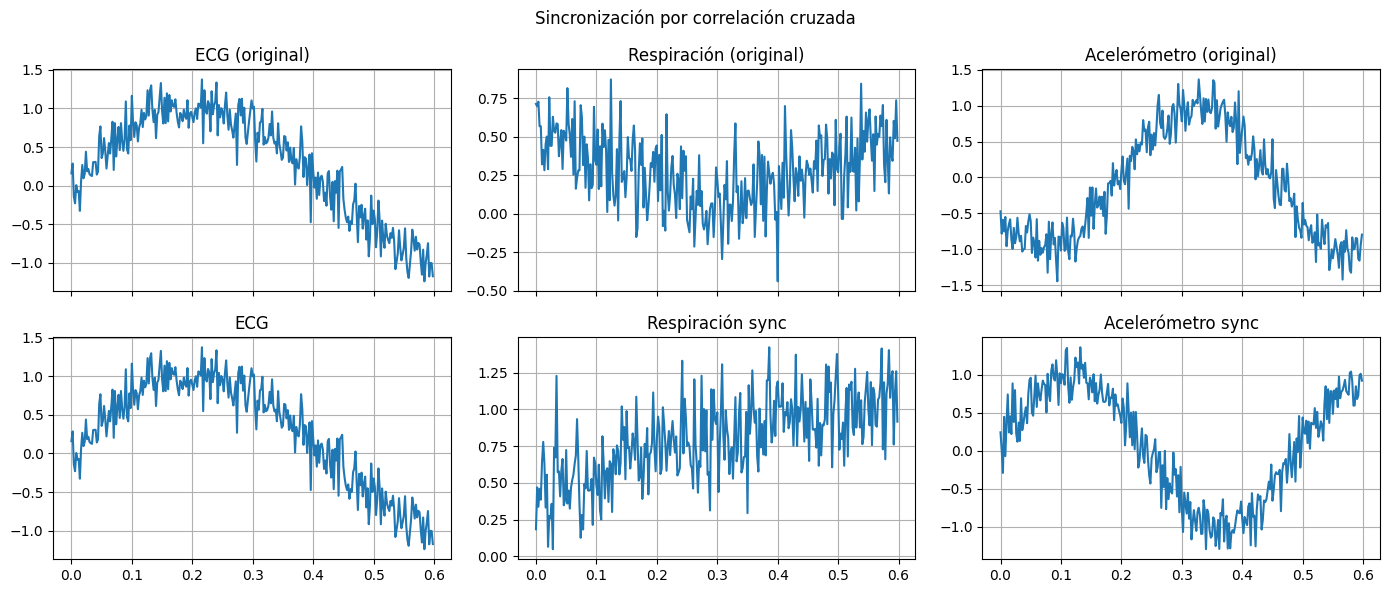

In [ ]:
fs=500
duracion=5
t=np.arange(0, duracion, 1/fs)
muestras=len(t)

#Señales con delays distintos
#Respiración llega 0.3 s tarde
delay2=int(0.3*fs)
#Acelerómetro llega 0.7 s tarde
delay3=int(0.7*fs)

#ECG (referencia)
s1=np.sin(2*np.pi*1.2*t) + 0.2*np.random.randn(muestras)
#Respiración
s2=np.roll(np.sin(2*np.pi*0.3*t), delay2) + 0.2*np.random.randn(muestras)
#Acelerómetro
s3=np.roll(np.sin(2*np.pi*2.0*t), delay3) + 0.2*np.random.randn(muestras)

#Estimar delay por correlación cruzada
def estimar_delay(referencia, señal):
    corr=correlate(referencia, señal, mode='full')
    lag=np.argmax(corr) - (len(referencia) - 1)
    return lag

lag2=estimar_delay(s1, s2)
lag3=estimar_delay(s1, s3)
print(f"Delay estimado respiración:  {lag2} muestras = {lag2/fs:.2f} s")
print(f"Delay estimado acelerómetro: {lag3} muestras = {lag3/fs:.2f} s")

#Corregir delays
s2_sync=np.roll(s2, -lag2)
s3_sync=np.roll(s3, -lag3)

#Graficamos
fig, axs=plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for i, (s, label) in enumerate([(s1,'ECG'), (s2,'Respiración'), (s3,'Acelerómetro')]):
    axs[0, i].plot(t[:300], s[:300]);
    axs[0, i].set_title(f"{label} (original)");
    axs[0,i].grid(True)
for i, (s, label) in enumerate([(s1,'ECG'), (s2_sync,'Respiración sync'), (s3_sync,'Acelerómetro sync')]):
    axs[1, i].plot(t[:300], s[:300]);
    axs[1, i].set_title(f"{label}");
    axs[1,i].grid(True)
plt.suptitle("Sincronización por correlación cruzada")
plt.tight_layout()
plt.show()

Ejercicio 6:

Simule:
* ECG a 500 Hz
* Respiración a 100 Hz
* Acelerómetro a 200 Hz

Lleve todas las señales a:
* 500 Hz y sincronícelas temporalmente.

Muestras originales → ECG: 2000, Resp: 400, Acel: 800
Muestras tras resample → Resp: 2000, Acel: 2000


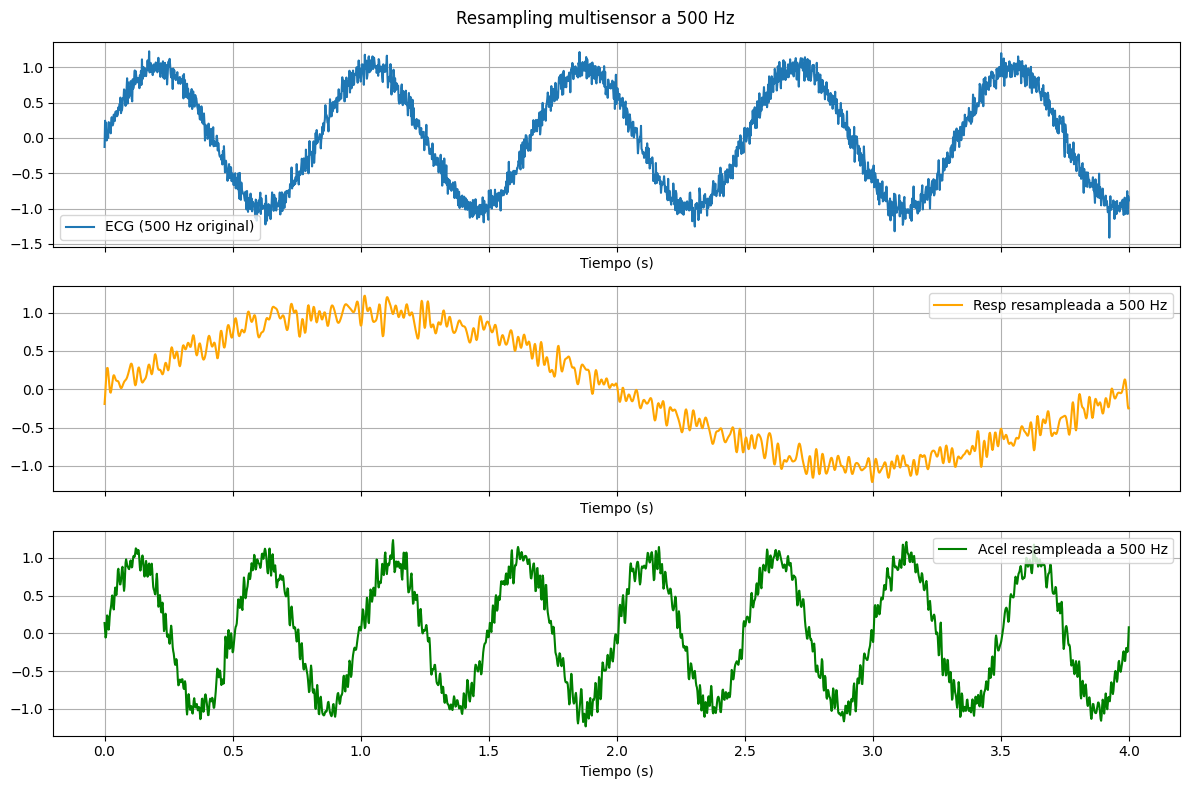

In [ ]:
duracion = 4

fs_ecg=500;
n_ecg=int(duracion*fs_ecg)
fs_resp=100;
n_resp=int(duracion*fs_resp)
fs_acel=200;
n_acel=int(duracion*fs_acel)

t_ecg=np.arange(n_ecg)/fs_ecg
t_resp=np.arange(n_resp)/fs_resp
t_acel=np.arange(n_acel)/fs_acel

ecg=np.sin(2*np.pi*1.2*t_ecg)  + 0.1*np.random.randn(n_ecg)
resp=np.sin(2*np.pi*0.25*t_resp) + 0.1*np.random.randn(n_resp)
acel=np.sin(2*np.pi*2.0*t_acel) + 0.1*np.random.randn(n_acel)

print(f"Muestras originales → ECG: {n_ecg}, Resp: {n_resp}, Acel: {n_acel}")

#Todo a 500 Hz
resp_500=resample(resp, n_ecg)
acel_500=resample(acel, n_ecg)

print(f"Muestras tras resample → Resp: {len(resp_500)}, Acel: {len(acel_500)}")

#Graficamos todo en el mismo eje
t_comun=t_ecg

fig, axs=plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axs[0].plot(t_comun, ecg, label=f"ECG ({fs_ecg} Hz original)")
axs[1].plot(t_comun, resp_500, label=f"Resp resampleada a {fs_ecg} Hz", color='orange')
axs[2].plot(t_comun, acel_500, label=f"Acel resampleada a {fs_ecg} Hz", color='green')
for ax in axs:
  ax.legend();
  ax.grid(True);
  ax.set_xlabel("Tiempo (s)")
plt.suptitle("Resampling multisensor a 500 Hz")
plt.tight_layout()
plt.show()